# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [20]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)


## 1. Generazione di un nuovo Sudoku

Viene usato un seed casuale, così ogni esecuzione completa del notebook tende a produrre un Sudoku nuovo. In questo modo non dovrebbe esistere già un'analisi salvata per la stessa griglia.


Seed: 97776876
Nome: generated_97776876
Numero di indizi: 30


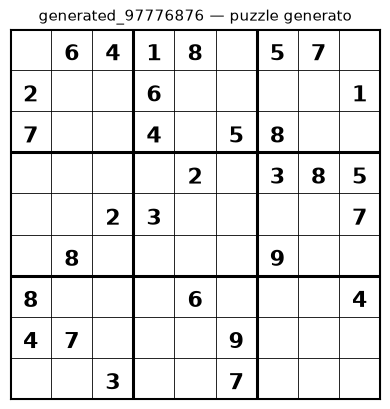

In [21]:
seed = random.SystemRandom().randrange(1, 10**9)
rng = random.Random(seed)

generated_puzzle, generated_solution = sg.generate_unique_puzzle(
    target_clues=30,
    rng=rng,
)

puzzle_name = f"generated_{seed}"

print("Seed:", seed)
print("Nome:", puzzle_name)
print("Numero di indizi:", int((generated_puzzle != 0).sum()))

sv.draw_grid(
    generated_puzzle,
    title=f"{puzzle_name} — puzzle generato",
)
plt.show()


## 2. Salvataggio del Sudoku

Il Sudoku viene salvato nella cartella `puzzles` dell'archivio. Il nome del file dipende dall'identificatore derivato dalla griglia.


In [22]:
saved_info = sa.save_sudoku(
    generated_puzzle,
    name=puzzle_name,
    metadata={
        "seed": seed,
        "target_clues": 30,
        "purpose": "test completo archivio e cache",
    },
)

print("Sudoku salvato")
print("ID:", saved_info["id"])
print("Nome:", saved_info["name"])
print("Percorso:", saved_info["path"])


Sudoku salvato
ID: eaf9831aef8074c05f72
Nome: generated_97776876
Percorso: sudoku_data\puzzles\eaf9831aef8074c05f72.json


## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


Sudoku caricato
ID: 2b85e16040791cd86bdb
Nome: 1
Percorso: sudoku_data\puzzles\2b85e16040791cd86bdb.json
Griglia identica all'originale: False


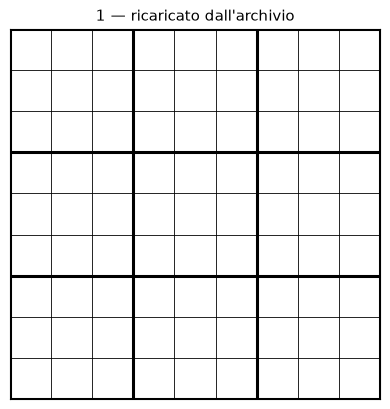

In [23]:
loaded_info = sa.load_sudoku('1')
loaded_puzzle = loaded_info["grid"]

print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])
print("Griglia identica all'originale:", (loaded_puzzle == generated_puzzle).all())

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


## 4. Prima analisi completa

Dato che il Sudoku è appena stato generato, la sua analisi non dovrebbe essere presente né nella cache in memoria né nell'archivio. La prima chiamata deve quindi:

1. eseguire il solver;
2. costruire la catena logica;
3. valutare la difficoltà;
4. salvare automaticamente l'analisi;
5. inserirla nella cache in memoria.


In [24]:
start = time.perf_counter()

first_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
)

first_elapsed = time.perf_counter() - start

print("Prima analisi completata")
print("Tempo:", round(first_elapsed, 4), "secondi")
print("Stato:", first_result["status"])
print("Valutazione:", first_result["grading"])
print("Numero di step:", len(first_result["chain"]))


Prima analisi completata
Tempo: 0.3097 secondi
Stato: stuck
Valutazione: {'label': 'N/A', 'max_difficulty': 0, 'max_level': 0, 'score': 0, 'workload_score': 0, 'histogram': {}, 'status': 'stuck', 'n_steps': 0}
Numero di step: 0


## 5. Visualizzazione della griglia risolta


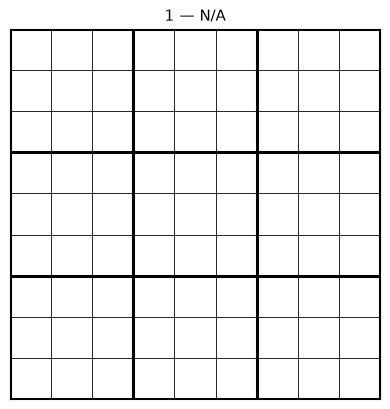

In [25]:
sv.draw_grid(
    first_result["solved_grid"],
    given_mask=(first_result["original"] != 0),
    title=(
        f"{first_result['name']} — "
        f"{first_result['grading']['label']}"
    ),
)
plt.show()


## 6. Catena di difficoltà

Mostra il livello di difficoltà usato a ogni step e il numero complessivo di passaggi per livello.


In [26]:
sv.plot_difficulty_chain(first_result)


Catena vuota: nulla da visualizzare.


## 7. Passaggio più difficile

Viene visualizzato lo stato della griglia in corrispondenza del passaggio con difficoltà massima.


In [27]:
if first_result["chain"]:
    hardest_index = max(
        range(len(first_result["chain"])),
        key=lambda index: first_result["chain"][index]["difficulty"],
    )

    hardest_move = first_result["chain"][hardest_index]

    print("Indice:", hardest_index)
    print("Step:", hardest_move["step"])
    print("Tecnica:", hardest_move["technique"])
    print("Difficoltà:", hardest_move["difficulty"])
    print("Descrizione:", hardest_move["description"])

    sv.draw_step(first_result, hardest_index)
else:
    print("Nessun passaggio disponibile.")


Nessun passaggio disponibile.


## 8. Tabella completa della catena


In [28]:
chain_dataframe = sv.summary_dataframe(first_result)
chain_dataframe


""


## 9. Frequenza delle tecniche effettivamente usate


In [29]:
technique_counts = (
    chain_dataframe["tecnica"]
    .value_counts()
    .rename_axis("tecnica")
    .reset_index(name="numero_step")
)

technique_counts


KeyError: 'tecnica'

## 10. Attività delle tecniche durante la risoluzione

Se `sudoku_visualization.py` contiene `plot_technique_activity`, viene mostrata la heatmap con:

- righe: tecniche;
- colonne: step;
- valori: numero di applicazioni disponibili in quello stato.

Le analisi devono contenere `applicable_by_technique` perché questa visualizzazione sia significativa.


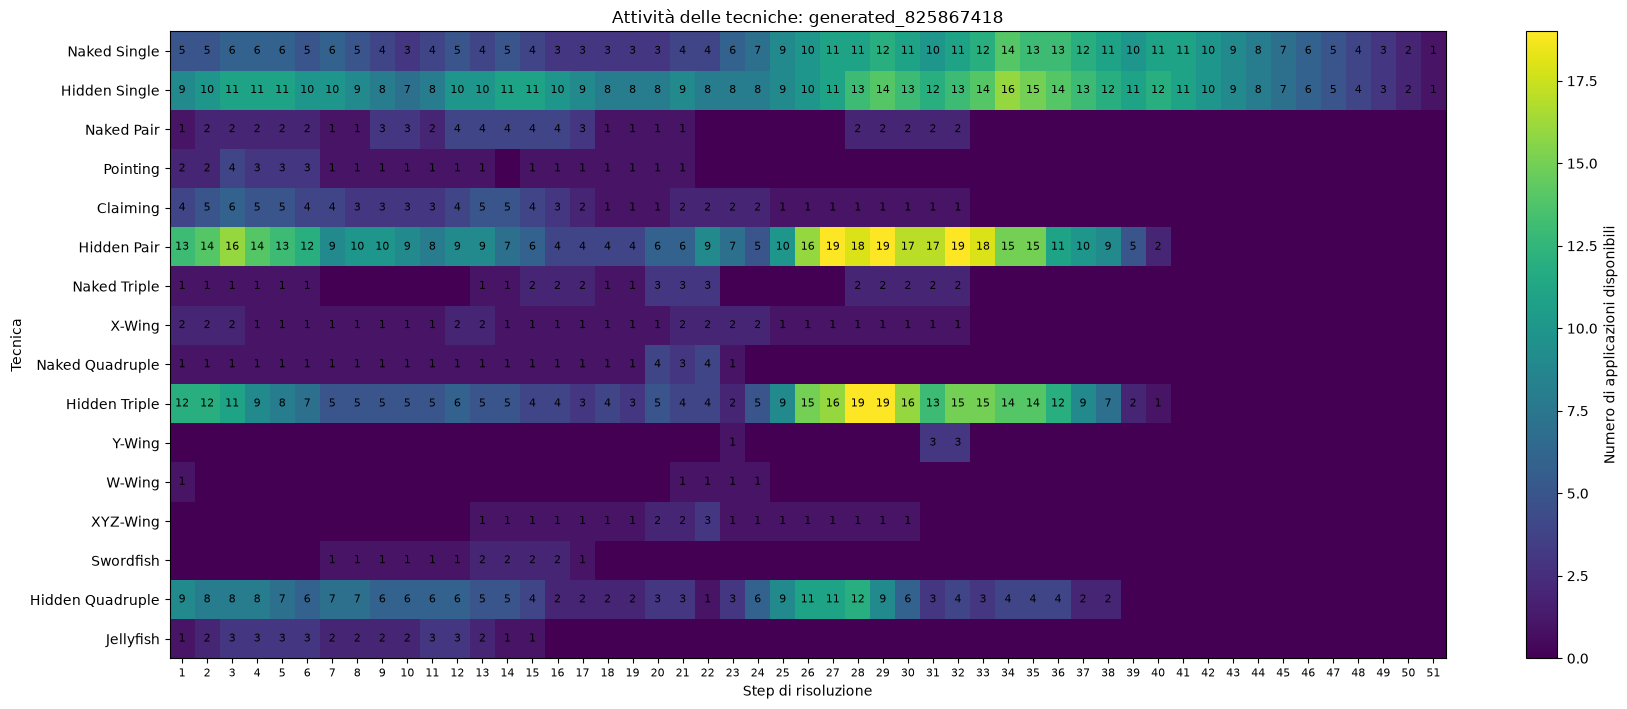

In [11]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )


## 11. Galleria

La galleria è pensata per più Sudoku, ma può essere usata anche con un solo risultato per verificare la vista riepilogativa.


In [12]:
sudoku_ref_list = sa.list_sudokus()
sudoku_list = [sa.load_sudoku(x['name']) for x in sudoku_ref_list]
sudoku_analysis_list = [sa.analyse_puzzle_cached(x['grid'], x['name']) for x in sudoku_list]

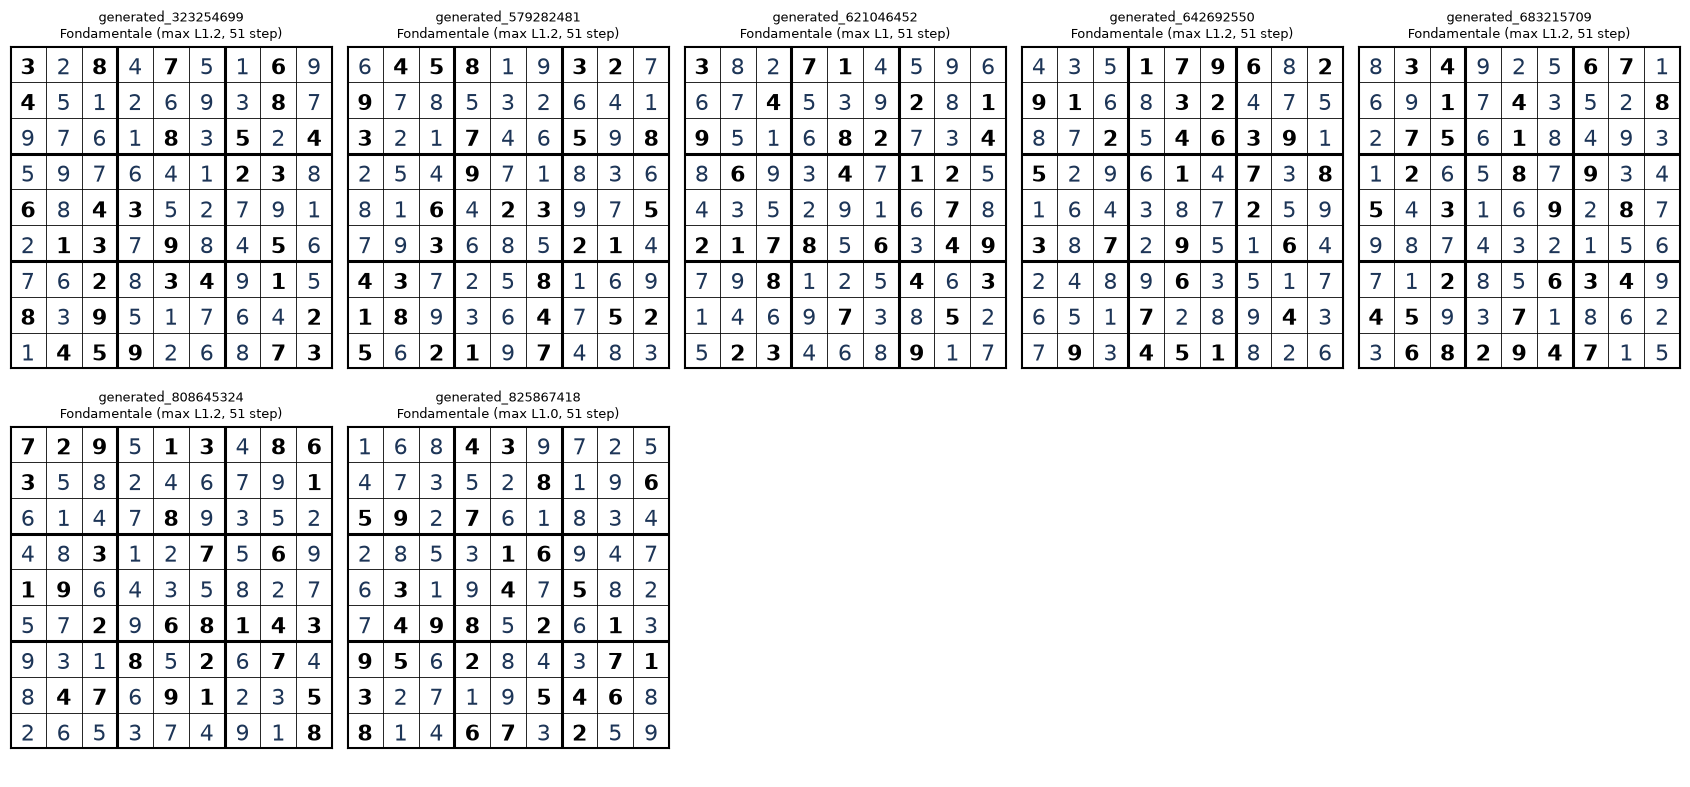

In [13]:
sv.gallery(sudoku_analysis_list, ncols=5)

## 12. Riepilogo sintetico


In [14]:
sv.analyses_summary_dataframe(sudoku_analysis_list)

,nome,stato,difficolta,difficolta_massima,livello_massimo,punteggio,numero_step,step_massimi,step_non_banali,step_avanzati,solvibile_verificato
0,generated_323254699,solved,Fondamentale,1.2,1,0.0,51,5.0,0.0,0.0,None
1,generated_579282481,solved,Fondamentale,1.2,1,0.0,51,11.0,0.0,0.0,None
2,generated_621046452,solved,Fondamentale,1.0,1,1.0,51,NaN,NaN,NaN,None
3,generated_642692550,solved,Fondamentale,1.2,1,0.0,51,3.0,0.0,0.0,None
4,generated_683215709,solved,Fondamentale,1.2,1,0.0,51,5.0,0.0,0.0,None
5,generated_808645324,solved,Fondamentale,1.2,1,0.0,51,5.0,0.0,0.0,None
6,generated_825867418,solved,Fondamentale,1.0,1,0.0,51,51.0,0.0,0.0,None


## 14. Controllo dell'archivio

Mostra l'elenco dei Sudoku salvati e verifica che quello appena creato risulti analizzato.


In [18]:
archive_dataframe = pd.DataFrame(sa.list_sudokus())
archive_dataframe


,id,name,clues,analysed,updated_at
0,ef428a80575d88acaa79,generated_323254699,30,True,2026-07-16T10:52:11.421115+00:00
1,6c79650f818830608fc1,generated_579282481,30,True,2026-07-16T10:52:11.426144+00:00
2,5799d0ae72e7f8e5753a,generated_621046452,30,True,2026-07-16T10:52:11.431114+00:00
3,6c356a2d49f91d6e784b,generated_642692550,30,True,2026-07-16T10:52:11.436113+00:00
4,a9544350224492ecf2a1,generated_683215709,30,True,2026-07-16T10:52:11.448122+00:00
5,3ab1d632c864c087c5e9,generated_808645324,30,True,2026-07-16T10:52:11.454119+00:00
6,a094e0c3b1f9cd0c705d,generated_825867418,30,True,2026-07-16T10:52:12.392768+00:00
